### **Овсянникова Майя ББИ241С**

## **Цель работы**

Исследовать различные факторы жизни и учебы студентов и их взаимосвязь: успеваемость, пол, аспекты образа жизни

## **Документация и теория**

Ниже перечислены основные используемые библиотеки работы с данными в данном проекте

**Загрузка и разведочный анализ данных**

**`pandas`** – основная библиотека для работы с табличными данными
* `pd.read_csv()` – загружает данные из csv-файла в объект `DataFrame`
* `df.head()`, `df.info()`, `df.describe()` – получение первичной информацией о данных
* `df.isnull().sum()`, `df.duplicated().sum()` – проверка наличия пропусков и дубликатов
* `df.select_dtypes()` – выбор колонок по типу данных


**`matplotlib.pyplot` и `seaborn`** – основные библиотеки для визуализации данных
* `.histplot()` – построение гистограмм для анализа распределения числовых признаков
* `.boxplot()` – построение ящиков с усами для выявления выбросов и анализа медианы и квартилей
* `.heatmap()` – построение тепловой карты для визуализации корреляционной матрицы
* `.kdeplot()` – построение графика плотности распределения
* `.pie()` – создание круговых диаграмм для отображения долей категориальных переменных

**`scipy.stats`** – библиотека для проведеня статистических тестов
* `.shapiro()` – тест Шапиро-Уилка для проверки нормальности распределения выборки
* `.chi2_contingency()` – критерий хи-квадрат для проверки независимости двух категориальных переменных
* `.ttest_ind()` – двухвыборочный t-тест для сравнения средних двух независимых групп
* `.f_oneway()` – однофакторный дисперсионный анализ ANOVA для сравнения средних трех и более групп
* `sklearn.utils.resample()` – метод для случайной передискретизации (bootstrap-выборки) массивов

**Построение и оценка моделей**

* `LabelEncoder()` – кодирование категориальных признаков в числовой формат
* `StandardScaler()` – стандартизация данных (приведение к среднему 0 и дисперсии 1)
* `sklearn.model_selection.train_test_split()` – разделение исходного набора данных на обучающую и тестовую выборки
* `sklearn.linear_model.LinearRegression` – линейная регрессия: модель для предсказания непрерывной целевой переменной
* `mean_squared_error()` (MSE) – среднеквадратичная ошибка
* `mean_absolute_error()` (MAE) – средняя абсолютная ошибка
* `r2_score()` (R2) – коэффициент детерминации, показывающий долю объясненной дисперсии модели
* `sklearn.cluster.KMeans` – кластеризация: модель для разделения данных на кластеры
* Метод локтя – анализ графика зависимости инерции (суммы квадратов расстояний до центров кластеров) от количества кластеров
* Коэффициент силуэта (`sklearn.metrics.silhouette_score`) – метрика, оценивающая, насколько объекты в своем кластере близки и насколько далеки от объектов в других кластерах
* `sklearn.decomposition.PCA` – метод главных компонент для уменьшения размерности данных (с 5 до 2 признаков) для их визуализации на плоскости

Выбранный датасет: **Lifestyle Factors and Their Impact on Students**

https://www.kaggle.com/datasets/charlottebennett1234/lifestyle-factors-and-their-impact-on-students/data

## **EDA**

#### **Загрузка данных и импорт библиотек**

In [304]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('student_lifestyle_dataset.csv')

df.head(5)

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,Gender,Grades
0,1,6.9,3.8,8.7,2.8,1.8,Moderate,Male,7.48
1,2,5.3,3.5,8.0,4.2,3.0,Low,Female,6.88
2,3,5.1,3.9,9.2,1.2,4.6,Low,Male,6.68
3,4,6.5,2.1,7.2,1.7,6.5,Moderate,Male,7.20
4,5,8.1,0.6,6.5,2.2,6.6,High,Male,8.78


#### **Проверка на пропуски и дубликаты**

In [305]:
print(f"Количество пропусков:\n{df.isnull().sum()}\n")
print(f"Количество дубликатов: {df.duplicated().sum()}")

Количество пропусков:
Student_ID                         0
Study_Hours_Per_Day                0
Extracurricular_Hours_Per_Day      0
Sleep_Hours_Per_Day                0
Social_Hours_Per_Day               0
Physical_Activity_Hours_Per_Day    0
Stress_Level                       0
Gender                             0
Grades                             0
dtype: int64

Количество дубликатов: 0


In [306]:
metric_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
metric_columns.remove('Student_ID')
print(f"metric_columns: {metric_columns}")

categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"categorical_columns: {categorical_columns}")

metric_columns: ['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'Grades']
categorical_columns: ['Stress_Level', 'Gender']


Датасет оказался хорошим, без пропущенных значений и дубликатов, как-либо удалять или заменять их не требуется

#### **Метрические переменные**

Посмотрим на распределения самой важной переменной датасета – оценки (`Grades`). Что интересно, распределение близко к нормальному. Все значения лежат в диапазоне 5-10, среднее, медиана и мода ≈7.8

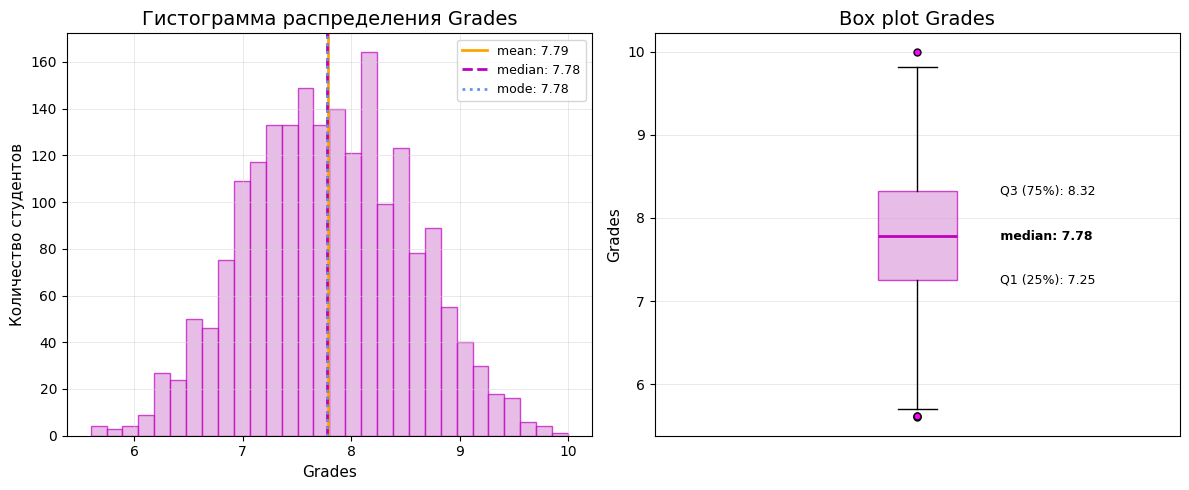

In [307]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

mean_val = df['Grades'].mean()
median_val = df['Grades'].median()
mode_val = df['Grades'].mode()[0]
q1 = df['Grades'].quantile(0.25)
q3 = df['Grades'].quantile(0.75)

axes[0].hist(df['Grades'], bins=30, color='plum', edgecolor='m', alpha=0.7)
axes[0].axvline(mean_val, color='orange', linestyle='-', linewidth=2, label=f'mean: {mean_val:.2f}')
axes[0].axvline(median_val, color='m', linestyle='--', linewidth=2, label=f'median: {median_val:.2f}')
axes[0].axvline(mode_val, color='cornflowerblue', linestyle=':', linewidth=2, label=f'mode: {mode_val:.2f}')
axes[0].set_title('Гистограмма распределения Grades', fontsize=14)
axes[0].set_xlabel('Grades', fontsize=11)
axes[0].set_ylabel('Количество студентов', fontsize=11)
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, color='lightgray', linewidth=0.5, alpha=0.7)

axes[1].boxplot(df['Grades'], patch_artist=True, boxprops=dict(facecolor='plum', color='m', alpha=0.7), medianprops=dict(color='m', linewidth=2), flierprops=dict(markerfacecolor='magenta', markersize=5))
axes[1].set_title('Box plot Grades', fontsize=14)
axes[1].set_xlabel('Распределение оценок', fontsize=11)
axes[1].set_ylabel('Grades', fontsize=11)
axes[1].grid(True, color='lightgray', linewidth=0.5, alpha=0.7)
axes[1].axes.get_xaxis().set_visible(False)

axes[1].text(1.15, median_val, f' median: {median_val:.2f}', verticalalignment='center', fontsize=9, color='k', fontweight='bold')
axes[1].text(1.15, q3, f' Q3 (75%): {q3:.2f}', verticalalignment='center', fontsize=9, color='k')
axes[1].text(1.15, q1, f' Q1 (25%): {q1:.2f}', verticalalignment='center', fontsize=9, color='k')

plt.tight_layout()
plt.show()

In [308]:
df[metric_columns].describe().round(2)

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Grades
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,7.48,1.99,7.50,2.70,4.33,7.79
std,1.42,1.16,1.46,1.69,2.51,0.75
min,5.00,0.00,5.00,0.00,0.00,5.60
25%,6.30,1.00,6.20,1.20,2.40,7.25
50%,7.40,2.00,7.50,2.60,4.10,7.78
75%,8.70,3.00,8.80,4.10,6.10,8.32
max,10.00,4.00,10.00,6.00,13.00,10.00


Все значения переменных лежат в адекватных для их смысла диапазонах, неотрицательных значений нет. Каких-либо ошибочных значений не выявлено

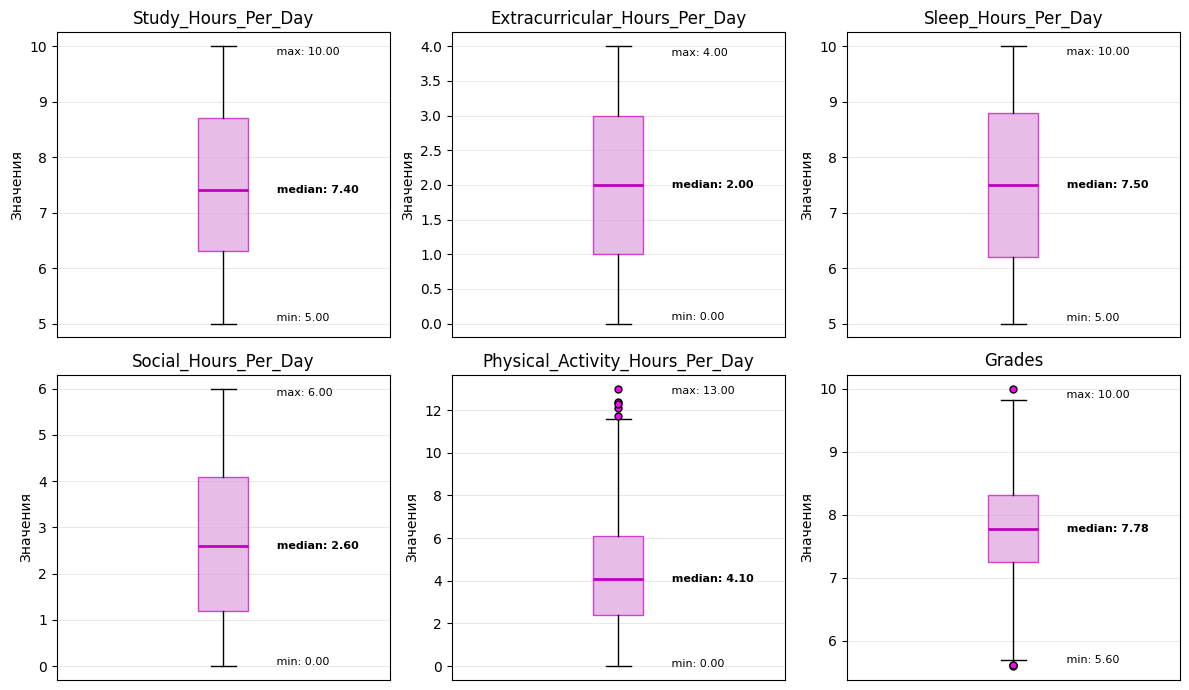

In [309]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()

for idx, col in enumerate(['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'Grades']):
    median_val = df[col].median()
    min_val = df[col].min()
    max_val = df[col].max()
    
    axes[idx].boxplot(df[col], patch_artist=True, boxprops=dict(facecolor='plum', color='m', alpha=0.7), medianprops=dict(color='m', linewidth=2),flierprops=dict(markerfacecolor='magenta', markersize=5))
    axes[idx].set_title(col, fontsize=12)
    axes[idx].axes.get_xaxis().set_visible(False)
    axes[idx].grid(True, color='lightgray', linewidth=0.5, alpha=0.7)
    axes[idx].set_ylabel('Значения', fontsize=10)
    
    axes[idx].text(1.15, median_val, f' median: {median_val:.2f}', verticalalignment='center', fontsize=8, color='k', fontweight='bold')
    axes[idx].text(1.15, min_val + 0.1, f' min: {min_val:.2f}', verticalalignment='center', fontsize=8, color='k')
    axes[idx].text(1.15, max_val - 0.1, f' max: {max_val:.2f}', verticalalignment='center', fontsize=8, color='k')

plt.tight_layout()
plt.show()

Выбросы есть только в двух переменных – `Physical_Activity_Hours_Per_Day` и `Grades`

Выведем их с помощью функции межквартильного размаха

In [310]:
def outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_series = series[(series < lower_bound) | (series > upper_bound)]
    return len(outliers_series), lower_bound, upper_bound, outliers_series

for col in metric_columns:
    count, lower, upper, outliers_data = outliers(df[col])
    
    print(f"\n{col} – {count} выбросов", end="")
    if count > 0:            
        print(":", end=" ")
        for idx, val in outliers_data.items():
                print(val, end=" ")



Study_Hours_Per_Day – 0 выбросов
Extracurricular_Hours_Per_Day – 0 выбросов
Sleep_Hours_Per_Day – 0 выбросов
Social_Hours_Per_Day – 0 выбросов
Physical_Activity_Hours_Per_Day – 5 выбросов: 13.0 12.4 12.1 12.3 11.7 
Grades – 4 выбросов: 10.0 5.62 5.6 5.62 

Полученные выбросы, как мне кажется, не являются погрешностью измерений или ошибкой в данных, они не являются некорректным значеним оценки, поэтому их предлагается оставить, как реальные данные, чтобы не исказить реальную картину при дальнейшем анализе

#### **Категориальные переменные**

In [311]:
df[categorical_columns].describe().head(2)

,Stress_Level,Gender
count,2000,2000
unique,3,2


Все категориальные атрибуты прнимают 3 для `Stress_Level` и 2 для `Gender` уникальных значения, каких-то некорректных случайных значений нет

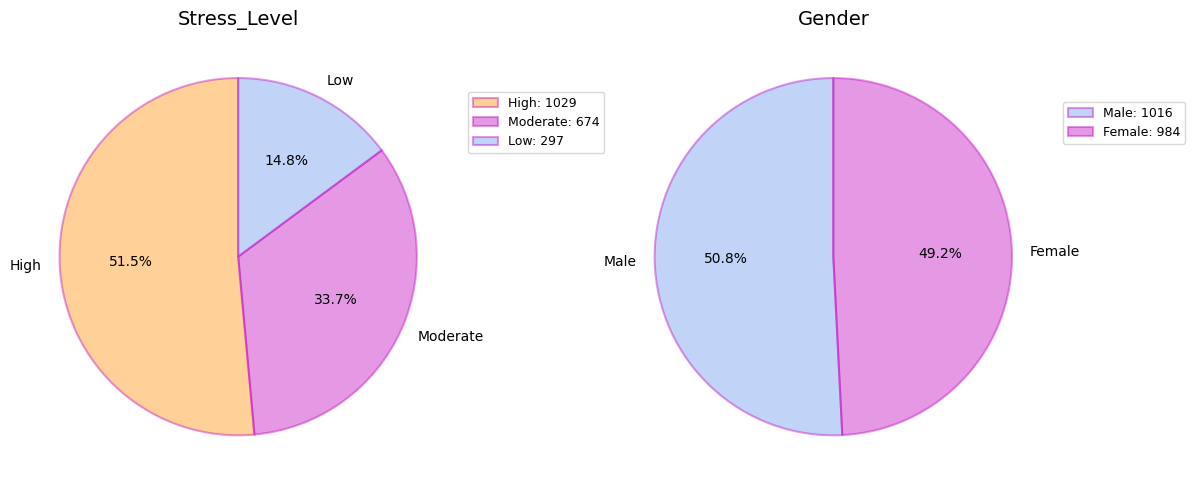

In [312]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

stress_counts = df['Stress_Level'].value_counts()
colors_stress = ['darkorange', 'm', 'cornflowerblue']
axes[0].pie(stress_counts.values, labels=stress_counts.index, autopct='%1.1f%%', colors=colors_stress, startangle=90, wedgeprops=dict(edgecolor='m', linewidth=1.5, alpha=0.4))
axes[0].set_title('Stress_Level', fontsize=14)

legend_labels = [f'{idx}: {count}' for idx, count in zip(stress_counts.index, stress_counts.values)]
axes[0].legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.8), fontsize=9, frameon=True, facecolor='white', edgecolor='lightgray',framealpha=0.9)


gender_counts = df['Gender'].value_counts()
colors_gender = ['cornflowerblue', 'm']
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', colors=colors_gender, startangle=90, wedgeprops=dict(edgecolor='m', linewidth=1.5, alpha=0.4)) 
axes[1].set_title('Gender', fontsize=14)

legend_labels = [f'{idx}: {count}' for idx, count in zip(gender_counts.index, gender_counts.values)]
axes[1].legend(legend_labels, loc='center left', bbox_to_anchor=(1, 0.8), fontsize=9, frameon=True, facecolor='white', edgecolor='lightgray', framealpha=0.9)

plt.tight_layout()
plt.show()

## **Проверка статистической гипотезы**

На двух выборках проведем сравнение среднего количества часов сна у студентов мужского и женского пола с помощью статистических тестов, проверив соответствие выборок условиям применимости

#### **Формулировка гипотез**

**H₀ (нулевая гипотеза):** Среднее количество часов сна в сутки у студентов мужского и женского пола одинаково

**H₁ (альтернативная гипотеза):** Среднее количество часов сна в сутки у студентов мужского и женского пола отличается

#### **Выбор статистического теста**

Предполагаем, что при соблюдении условий применимости, будем использовать **независимый (двухвыборочный) t-тест**, поскольку
+ проводится сравнение 2 выборок
+ выборки независимы (разделение по полу `Male` / `Female`)
+ проверяем гипотезы о равнестве средних (количественные данные)

**Критерии применимости t-теста**
+ независимость данных (соблюдается)
+ нормальность распределения в каждой выборке (проверим)
+ равенство дисперсий (проверим)

Уровень значимости стандартно задаем $\alpha = 0.05$

In [313]:
male_sleep = df[df['Gender'] == 'Male']['Sleep_Hours_Per_Day']
female_sleep = df[df['Gender'] == 'Female']['Sleep_Hours_Per_Day']

print(f"Male: n = {len(male_sleep)}, mean = {male_sleep.mean():.2f}, var = {male_sleep.var(ddof=1):.2f}")
print(f"Female: n = {len(female_sleep)}, mean = {female_sleep.mean():.2f}, var = {female_sleep.var(ddof=1):.2f}")

Male: n = 1016, mean = 7.53, var = 2.15
Female: n = 984, mean = 7.48, var = 2.12


#### **Проверка нормальности распределений**

Для проверки нормальности распределений используем тест Шапиро-Уилка

In [314]:
shapiro_male = stats.shapiro(male_sleep)
shapiro_female = stats.shapiro(female_sleep)

print(f"Male: тест Шапиро–Уилка p_value = {shapiro_male.pvalue:.2f}")
print(f"Female: тест Шапиро–Уилка p_value = {shapiro_female.pvalue:.2f}")

Male: тест Шапиро–Уилка p_value = 0.00
Female: тест Шапиро–Уилка p_value = 0.00


По результатам теста в обоих выборках `p_value = 0.00 < alpha = 0.05`

То есть $p_{value}$ меньше уровня статистической значимости, а значим мы **отвергаем** нулевую гипотезу теста Шапиро-Уилка от том, что данные в выборках распределены нормально

Распределение данных в выборках нельзя назвать нормальным и наша идея применить t-тест **не** может быть реализована

Убедимся в том, что распределение не нормальное, на графиках:

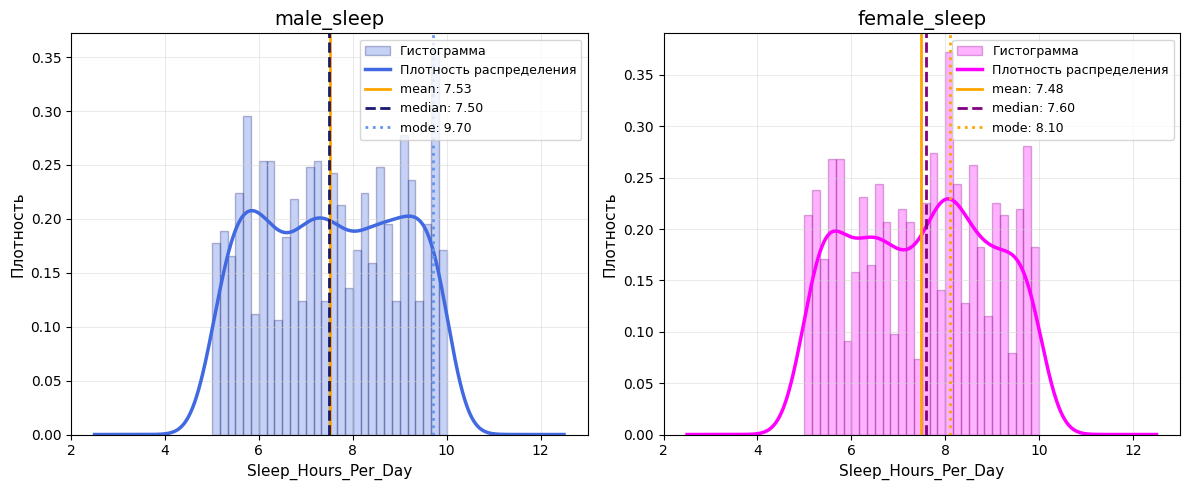

In [315]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

male_mean = male_sleep.mean()
male_median = male_sleep.median()
male_mode = male_sleep.mode()[0]

female_mean = female_sleep.mean()
female_median = female_sleep.median()
female_mode = female_sleep.mode()[0]

axes[0].hist(male_sleep, bins=30, density=True, alpha=0.3, color='royalblue', edgecolor='midnightblue', label='Гистограмма')
male_kde = male_sleep.plot.kde(ax=axes[0], color='royalblue', linewidth=2.5, label='Плотность распределения')
axes[0].axvline(male_mean, color='orange', linestyle='-', linewidth=2, label=f'mean: {male_mean:.2f}')
axes[0].axvline(male_median, color='midnightblue', linestyle='--', linewidth=2, label=f'median: {male_median:.2f}')
axes[0].axvline(male_mode, color='cornflowerblue', linestyle=':', linewidth=2, label=f'mode: {male_mode:.2f}')
axes[0].set_title('male_sleep', fontsize=14)
axes[0].set_xlabel('Sleep_Hours_Per_Day', fontsize=11)
axes[0].set_ylabel('Плотность', fontsize=11)
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, color='lightgray', linewidth=0.5, alpha=0.7)


axes[1].hist(female_sleep, bins=30, density=True, alpha=0.3, color='magenta', edgecolor='purple', label='Гистограмма')
female_kde = female_sleep.plot.kde(ax=axes[1], color='magenta', linewidth=2.5, label='Плотность распределения')
axes[1].axvline(female_mean, color='orange', linestyle='-', linewidth=2, label=f'mean: {female_mean:.2f}')
axes[1].axvline(female_median, color='purple', linestyle='--', linewidth=2, label=f'median: {female_median:.2f}')
axes[1].axvline(female_mode, color='orange', linestyle=':', linewidth=2, label=f'mode: {female_mode:.2f}')
axes[1].set_title('female_sleep', fontsize=14)
axes[1].set_xlabel('Sleep_Hours_Per_Day', fontsize=11)
axes[1].set_ylabel('Плотность', fontsize=11)
axes[1].legend(loc='upper right', fontsize=9)
axes[1].grid(True, color='lightgray', linewidth=0.5, alpha=0.7)


plt.tight_layout()
plt.show()

Для дальнейшего анализа выберу **Bootstrap-тест**. В отличии от U-критерия Манна-Уитни, который также не требует нормальности распределений, bootstrap позволяет сравнивать именно средние\*

\* H₀ и H₁ соответственно сохраняются в прежней формулировке

**Критерии применимости bootstrap-теста**
+ независимость данных (соблюдается)
+ достаточный размер выборки (соблюдается, $n_{male} = 1016$, $n_{female} = 984$)
+ выборка отражает генеральную совокупность (соблюдается)
+ отсутствие существенных выбросов (визуально соблюдается, но лучше проверить)

Bootstrap может быть чувствителен к сильно разным дисперсиям и крайней асимметрии, но в данном случае, исходя из преданализа выше (дисперсии, графики и очистка выбросов) у нас классический bootstrap должен работать корректно



In [316]:
from sklearn.utils import resample

def bootstrap_mean_test(group1, group2, n=10000, ci_level=0.95):
    observed_diff = np.mean(group1) - np.mean(group2)
    conc = np.concatenate([group1, group2])
    
    bootstrap_diffs = []
    
    for i in range(n):
        sample1 = resample(conc, n_samples=len(group1), replace=True, random_state=i)
        sample2 = resample(conc, n_samples=len(group2), replace=True, random_state=i + 10000)

        bootstrap_diff = np.mean(sample1) - np.mean(sample2)
        bootstrap_diffs.append(bootstrap_diff)
    
    bootstrap_diffs = np.array(bootstrap_diffs)
    p_value = np.mean(np.abs(bootstrap_diffs) >= np.abs(observed_diff))

    alpha = 1 - ci_level
    ci_lower = np.percentile(bootstrap_diffs, 100 * alpha/2)
    ci_upper = np.percentile(bootstrap_diffs, 100 * (1 - alpha/2))
    
    return observed_diff, p_value, bootstrap_diffs, ci_lower, ci_upper

observed_diff, p_value, bootstrap_diffs, ci_lower, ci_upper = bootstrap_mean_test(male_sleep, female_sleep, n=10000)

print(f"Наблюдаемая разница средних Male – Female: {observed_diff:.2f}")
print(f"Bootstrap p-value: {p_value:.2f}")

Наблюдаемая разница средних Male – Female: 0.05
Bootstrap p-value: 0.45


По результатам теста `p_value = 0.42 > alpha = 0.05` – значительно больше уровня статистической значимости $\alpha$, а значим мы **не отвергаем** нулевую гипотезу

То есть действительно **Среднее количество часов сна в сутки у студентов мужского и женского пола одинаково**

## **Анализ взаимосвязи переменных**

#### **Оценка взаимосвязей метрических параметров — матрица корреляций**

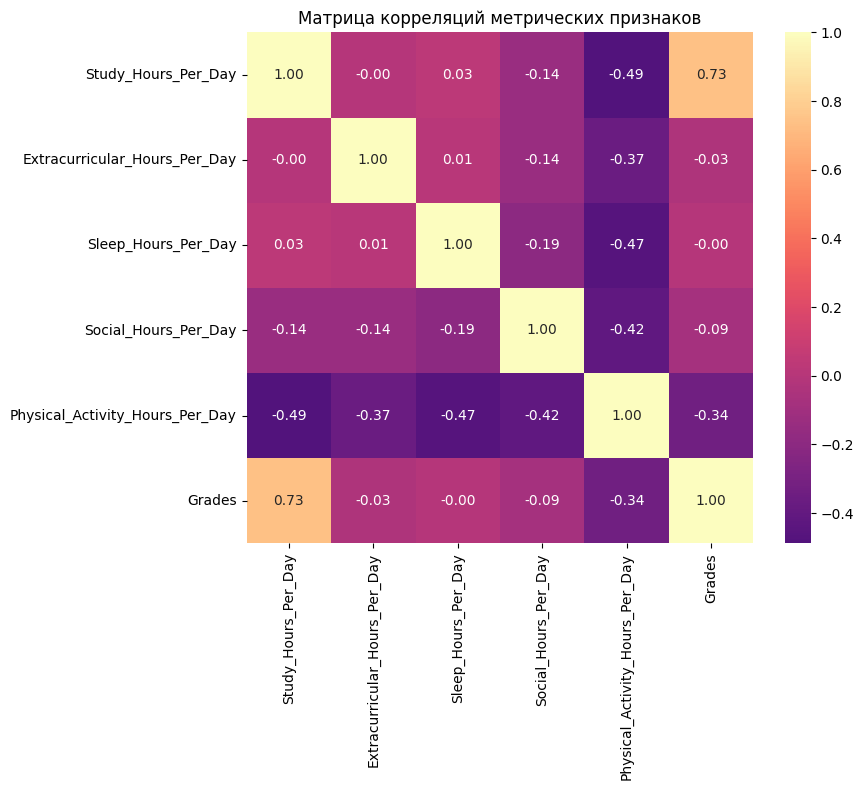

In [317]:
corr_matrix = df[metric_columns].corr()

plt.figure(figsize=(9, 8))
sns.heatmap(corr_matrix, annot=True, cmap='magma', center=0, fmt='.2f')
plt.title('Матрица корреляций метрических признаков')

plt.tight_layout()
plt.show()

Можно заметить, что наибольшую корреляцию имеют атрибуты `Grades` и `Study_Hours_Per_Day`. Это довольно логично – чем больше студент тратит времени в день на учебу, тем лучше должны быть его оценки

Что интересно, корреляция между `Grades` и `Sleep_Hours_Per_Day` ≈ 0.00

В моем предположении между этими атрибутами должна бы быть неслабая прямая корреляция – ведь, чем больше спит и соответственно лучше высыпается студент, тем лучше должны быть его оценки и успеваемость (без ухода в крайности и слишком большое количества сна в день, которое мешает учебе). Но, исходя из корреляции, никакой прямой линейной зависимости не наблюдается. Возможно тут более сложная зависимость – квадратичная функция? (Парабола ветками вниз – при большом дефиците и слишком большом количестве сна в день оценки плохие, а в середине самые лучшие). Для проверки предположения построим линейный график:

In [318]:
df['Sleep_Hours_Rounded'] = df['Sleep_Hours_Per_Day'].round()
sleep_grades = df.groupby('Sleep_Hours_Rounded')['Grades'].agg(['mean', 'std', 'count']).reset_index()

display(sleep_grades.round(2))

,Sleep_Hours_Rounded,mean,std,count
0,5.0,7.86,0.73,192
1,6.0,7.73,0.69,439
2,7.0,7.83,0.74,333
3,8.0,7.85,0.74,467
4,9.0,7.74,0.78,335
5,10.0,7.75,0.82,234


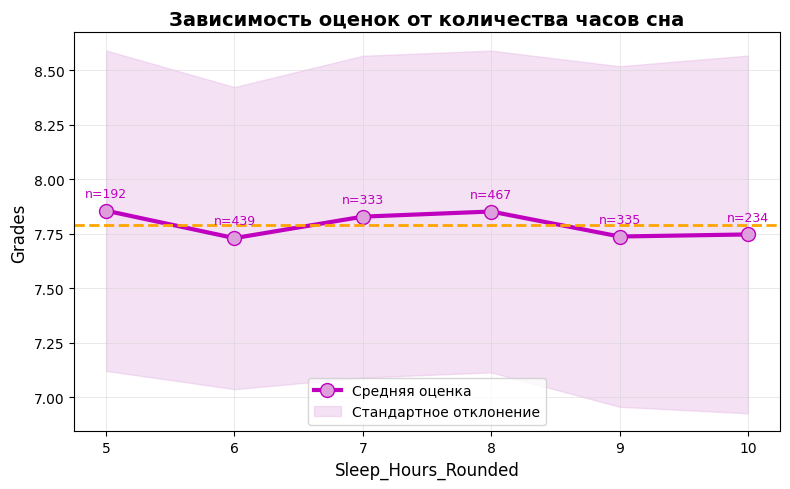

In [319]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(sleep_grades['Sleep_Hours_Rounded'], sleep_grades['mean'], 'o-', color='m', linewidth=3, markersize=10, markerfacecolor='plum', markeredgecolor='m', label='Средняя оценка')
ax.fill_between(sleep_grades['Sleep_Hours_Rounded'], sleep_grades['mean'] - sleep_grades['std'], sleep_grades['mean'] + sleep_grades['std'], color='plum', alpha=0.3, label='Стандартное отклонение')

for i, row in sleep_grades.iterrows():
    ax.annotate(f'n={int(row["count"])}', (row['Sleep_Hours_Rounded'], row['mean']), textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, color='m')

ax.set_xlabel('Sleep_Hours_Rounded', fontsize=12)
ax.set_ylabel('Grades', fontsize=12)
ax.set_title('Зависимость оценок от количества часов сна', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, color='lightgray', linewidth=0.5, alpha=0.7)

mean_grade = df['Grades'].mean()
ax.axhline(y=mean_grade, color='orange', linestyle='--', linewidth=2, label=f'Средняя оценка: {mean_grade:.2f}')

plt.tight_layout()
plt.show()

Но нет, никакой квадратичной зависимости на графике не наблюдается. Подробнее о средней оценке для каждой категории количества сна можно также посмотреть благодаря функции группировки и агрегации выше

#### **Оценка взаимосвязей неметрических параметров — $\chi^2$**

In [320]:
from scipy.stats import chi2_contingency

chi2, p, dof, expected = chi2_contingency(pd.crosstab(df['Stress_Level'], df['Gender']))
print(f"Хи-квадрат p-value: {p:.2f}")

Хи-квадрат p-value: 0.70


У нас всего 2 неметрических параметра – `Stress_Level` и `Gender`, для оценки связи между ними используем критерий Хи-квадрат

`p-value = 0.74 > alpha = 0.05` говорит о том, что у нас нет оснований отвергнуть нулевую гипотезу **H₀** критерия $\chi^2$ о том, что переменные независимы

То есть нет статистически значимой связи между уровнем стресса и полом студента

#### **Оценка связи между категориальными переменными и метрическими — t-тест и ANOVA**

Используем функции `ttest_ind` и `f_oneway` из библиотеки `SciPy.stats` для проведение t-теста для 2х групп и ANOVA теста для 3х групп

In [321]:
from scipy.stats import ttest_ind
from scipy.stats import f_oneway

for cat in categorical_columns:
    for met in metric_columns:
            if df[cat].nunique() == 2: # t-test для 2 групп
                groups = [df[df[cat] == val][met] for val in df[cat].unique()]
                t_stat, p_val = ttest_ind(groups[0], groups[1], nan_policy='omit')
                print(f"{cat} — {met}: p-value = {p_val:.2f}")

            elif df[cat].nunique() > 2: # ANOVA для > 2 групп
                groups = [df[df[cat] == val][met] for val in df[cat].unique()]
                f_stat, p_val = f_oneway(*groups)
                print(f"{cat} — {met}: p-value = {p_val:.2f}")   

Stress_Level — Study_Hours_Per_Day: p-value = 0.00
Stress_Level — Extracurricular_Hours_Per_Day: p-value = 0.90
Stress_Level — Sleep_Hours_Per_Day: p-value = 0.00
Stress_Level — Social_Hours_Per_Day: p-value = 0.05
Stress_Level — Physical_Activity_Hours_Per_Day: p-value = 0.00
Stress_Level — Grades: p-value = 0.00
Gender — Study_Hours_Per_Day: p-value = 0.12
Gender — Extracurricular_Hours_Per_Day: p-value = 0.64
Gender — Sleep_Hours_Per_Day: p-value = 0.45
Gender — Social_Hours_Per_Day: p-value = 0.65
Gender — Physical_Activity_Hours_Per_Day: p-value = 0.16
Gender — Grades: p-value = 0.54


Есть статистически значимая сильная связь между `Stress_Level` и `Study_Hours_Per_Day`, `Sleep_Hours_Per_Day`, `Physical_Activity_Hours_Per_Day` и `Grades` (`p-value` значительно меньше 0.05, близок к 0.00)

Каждая эта связь логично интерпретируется

Для `Gender` нет статистически значимой связи между полом студента и метрическими переменными

## **Построение модели линейной регрессии**

#### **Импорт необходимых библиотек**

In [322]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

#### **Очистка от выбросов, проверка на мультиколлинеарность**

Для построения модели линейной регрессии важно провести очистку данных от выбросов, потому что линейная регрессия минимизирует сумму квадратов ошибок **MSE**, которая к ним сильно чувствительна. Выбросы мы уже удалили ранее, также, как и проверили данные на отсутствие пустых значений и дубликатов

Чуть выше мы также уже строили матрицу корреляций, которая показала, что мультиколлинеарности не выявлено

#### **Кодирование категориальных переменных**

Кодируем категориальные переменные (для `Stress_Level_Encoded` удобнеее использовать маппинг, поскольку иначе присвоение "не по возрастанию")

In [323]:
label_encoder_gender = LabelEncoder()
df['Gender_Encoded'] = label_encoder_gender.fit_transform(df['Gender'])

stress_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
df['Stress_Level_Encoded'] = df['Stress_Level'].map(stress_mapping)

df.head(5)

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Stress_Level,Gender,Grades,Sleep_Hours_Rounded,Gender_Encoded,Stress_Level_Encoded
0,1,6.9,3.8,8.7,2.8,1.8,Moderate,Male,7.48,9.0,1,1
1,2,5.3,3.5,8.0,4.2,3.0,Low,Female,6.88,8.0,0,0
2,3,5.1,3.9,9.2,1.2,4.6,Low,Male,6.68,9.0,1,0
3,4,6.5,2.1,7.2,1.7,6.5,Moderate,Male,7.20,7.0,1,1
4,5,8.1,0.6,6.5,2.2,6.6,High,Male,8.78,6.0,1,2


#### **Выбор признаков для модели**

Выбираем числовые признаки (исключаем `Student_ID`, исходные категориальные и саму целевую переменную `Grades`)

Мы выбрали все метрические переменные (кроме целевой и айдишника) и закодированные категориальные — итого 7 признаков, так как это было первым предположением, которое попадает в идеальное количество параметров для модели:
> Для линейной регрессии оптимально:
> - минимум: 1-2 ключевых признака
> - хорошо: 3-7 признаков
> - максимум: не более $n$/(10 ... 20), где $n$ — число наблюдений

В отдельном ноутбуке, посвященном только модели линейной регрессии, была также построена модель из 5 признаков (исключив наименее значимые коэффициенты), но метрики модели практически не изменились. Данные признаки показали неплохой результат, поэтому были выбраны оптимальными:

Признаки **X**: `Study_Hours_Per_Day`, `Extracurricular_Hours_Per_Day`, `Sleep_Hours_Per_Day`, `Social_Hours_Per_Day`, `Physical_Activity_Hours_Per_Day`, `Gender_Encoded`, `Stress_Level_Encoded`

Целевая переменная **y**: `Grades`

In [324]:
features_for_linear = ['Study_Hours_Per_Day',
                       'Extracurricular_Hours_Per_Day', 
                       'Sleep_Hours_Per_Day',
                       'Social_Hours_Per_Day',
                       'Physical_Activity_Hours_Per_Day',
                       'Gender_Encoded',
                       'Stress_Level_Encoded']

X = df[features_for_linear]
y = df['Grades'] 

Вспомним распределение и характеристики целевой переменной `Grades`

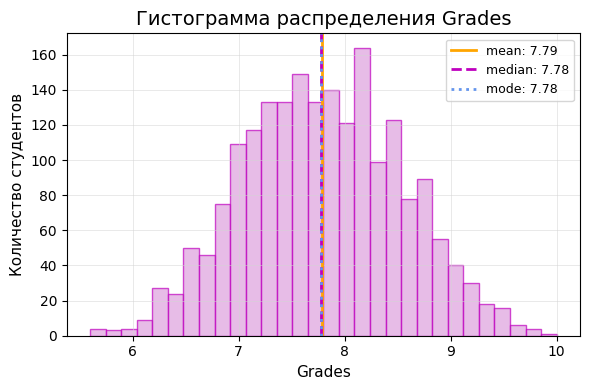

In [325]:
fig, axes = plt.subplots(figsize=(6, 4))

mean_val = df['Grades'].mean()
median_val = df['Grades'].median()
mode_val = df['Grades'].mode()[0]

plt.hist(df['Grades'], bins=30, color='plum', edgecolor='m', alpha=0.7)
plt.axvline(mean_val, color='orange', linestyle='-', linewidth=2, label=f'mean: {mean_val:.2f}')
plt.axvline(median_val, color='m', linestyle='--', linewidth=2, label=f'median: {median_val:.2f}')
plt.axvline(mode_val, color='cornflowerblue', linestyle=':', linewidth=2, label=f'mode: {mode_val:.2f}')
plt.title('Гистограмма распределения Grades', fontsize=14)
plt.xlabel('Grades', fontsize=11)
plt.ylabel('Количество студентов', fontsize=11)
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, color='lightgray', linewidth=0.5, alpha=0.7)


plt.tight_layout()
plt.show()

In [326]:
print(f"Grades mean: {df['Grades'].mean():.2f}")
print(f"Grades median: {df['Grades'].median():.2f}")
print(f"Grades std: {df['Grades'].std():.2f}")
print(f"Grades min: {df['Grades'].min():.2f}")
print(f"Grades max: {df['Grades'].max():.2f}")

Grades mean: 7.79
Grades median: 7.78
Grades std: 0.75
Grades min: 5.60
Grades max: 10.00


#### **Обучение модели**

##### Разделение на обучающую и тестовую выборки

In [327]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nРазмер обучающей выборки: {X_train.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")


Размер обучающей выборки: 1600
Размер тестовой выборки: 400


##### Масштабирование признаков

Линейная регрессия чувствительна к масштабу признаков. Стандартизация ставит все признаки в один "вес", чтобы модель могла корректно оценить их важность (коэффициенты)

In [328]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##### Создание и обучение модели линейной регрессии, предсказания

In [329]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

#### **Оценка модели**
- **MSE** – среднеквадратичная ошибка
- **RMSE** – корень из среднеквадратичнрй ошибки
- **MAE** – средняя абсолютная ошибка
- **R2** – коэффициент детерминации (показывает, какую долю дисперсии целевой переменной объясняет модель; чем ближе к 1, тем лучше)

##### Метрики для обучающей выборки

In [330]:
train_mse = mean_squared_error(y_train, y_train_pred)
train_rmse = np.sqrt(train_mse)
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print("Обучающая выборка")
print(f"MSE: {train_mse:.4f}")
print(f"RMSE: {train_rmse:.4f}")
print(f"MAE: {train_mae:.4f}")
print(f"R2: {train_r2:.4f}")

Обучающая выборка
MSE: 0.2540
RMSE: 0.5040
MAE: 0.3982
R2: 0.5388


##### Метрики для тестовой выборки

In [331]:
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Тестовая выборка")
print(f"MSE: {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")
print(f"R2: {test_r2:.4f}")

Тестовая выборка
MSE: 0.2640
RMSE: 0.5138
MAE: 0.4109
R2: 0.5478


##### Коэффициенты модели

In [332]:
coefficients = pd.DataFrame({'Признак': features_for_linear,'Коэффициент': model.coef_})
coefficients = coefficients.sort_values('Коэффициент', key=abs, ascending=False)
print(coefficients.round(4))

print(f"\nСвободный член: {model.intercept_:.4f}")

                           Признак  Коэффициент
0              Study_Hours_Per_Day       0.4723
4  Physical_Activity_Hours_Per_Day      -0.1239
1    Extracurricular_Hours_Per_Day      -0.0860
2              Sleep_Hours_Per_Day      -0.0820
3             Social_Hours_Per_Day      -0.0807
5                   Gender_Encoded      -0.0166
6             Stress_Level_Encoded       0.0049

Свободный член: 7.7924


#### **Визуализация результатов**

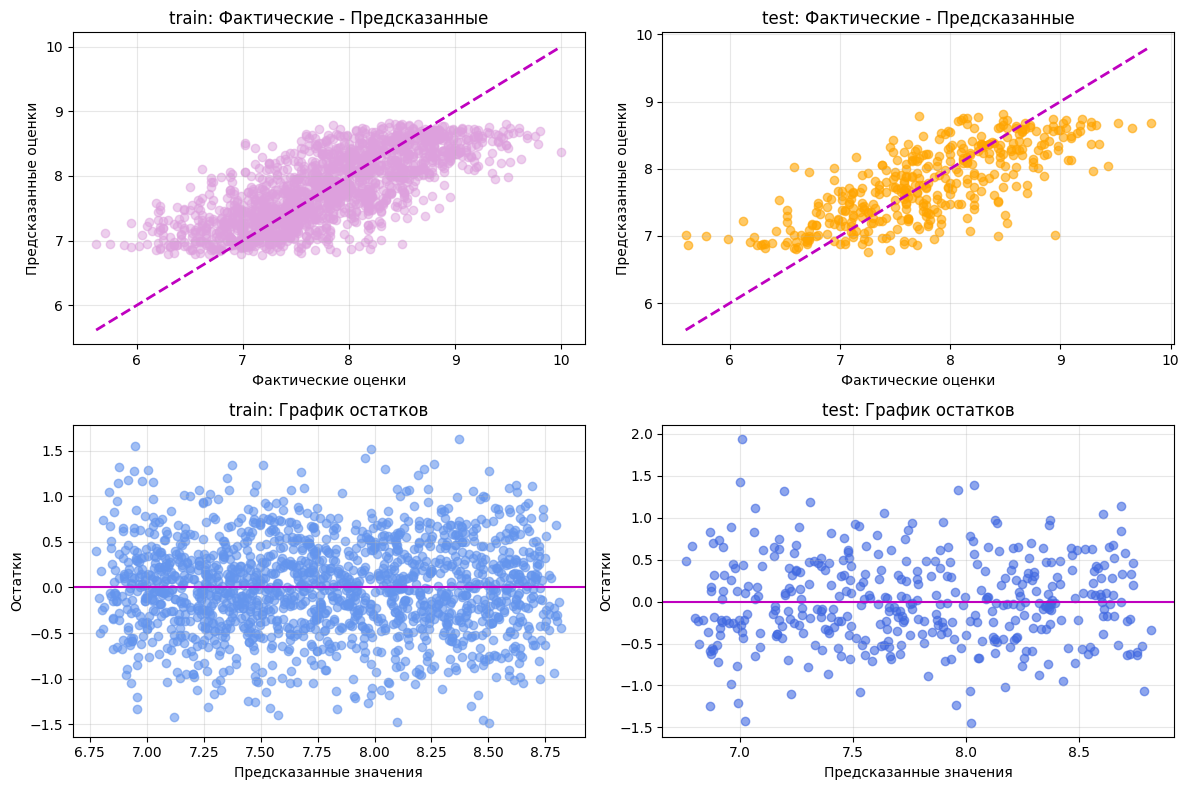

In [333]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].scatter(y_train, y_train_pred, alpha=0.5, color='plum')
axes[0, 0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], '--', lw=2, color='m')
axes[0, 0].set_xlabel('Фактические оценки')
axes[0, 0].set_ylabel('Предсказанные оценки')
axes[0, 0].set_title('train: Фактические - Предсказанные')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(y_test, y_test_pred, alpha=0.6, color='orange')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', lw=2, color='m')
axes[0, 1].set_xlabel('Фактические оценки')
axes[0, 1].set_ylabel('Предсказанные оценки')
axes[0, 1].set_title('test: Фактические - Предсказанные')
axes[0, 1].grid(True, alpha=0.3)

residuals_train = y_train - y_train_pred
axes[1, 0].scatter(y_train_pred, residuals_train, alpha=0.6, color='cornflowerblue')
axes[1, 0].axhline(y=0, color='m')
axes[1, 0].set_xlabel('Предсказанные значения')
axes[1, 0].set_ylabel('Остатки')
axes[1, 0].set_title('train: График остатков')
axes[1, 0].grid(True, alpha=0.3)

residuals_test = y_test - y_test_pred
axes[1, 1].scatter(y_test_pred, residuals_test, alpha=0.6, color='royalblue')
axes[1, 1].axhline(y=0, color='m')
axes[1, 1].set_xlabel('Предсказанные значения')
axes[1, 1].set_ylabel('Остатки')
axes[1, 1].set_title('test: График остатков')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### **Выводы**

- **RMSE** `(0.51)` и **MAE** `(0.41)` показывают, что в среднем модель ошибается при предсказании оценки студента примерно на 0,41-0,51 балла. Так как диапазон `Grades` в датасете составляет примерно от 5.5 до 9 баллов, ошибка в 0.5 балла является вполне приемлемой, модель может довольно точно предсказать оценку. То, что **RMSE** выше, чем **MAE**, говорит о наличии небольших выбросов (**RMSE** через квадрат сильнее реагирует на них)

- **R2** `(0.5487)` означает, что модель объясняет около 55% вариации (дисперсии) оценок студентов. То есть чуть более половины того, почему один студент учится лучше другого, можно объяснить теми факторами, которые мы включили в модель
Это довольно логично, например, остальныим могли быть такие факторы: мотивация, как-либо измеренные способности, первоначальный уровень подготовки и тд

- Наибольший положительный эффект на оценку оказывает количество часов учебы в день `Study_Hours_Per_Day`, мы также это получили матрицей корреляций

Итого, модель имеет достаточно хороший уровень точности предсказаний

## **Построение модели кластеризации**

#### **Импорт необходимых библиотек**

In [334]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA

#### **Выбор признаков для модели**

Для кластеризации образа жизни выберем все колонки, связанные с распределением времени:
- `Study_Hours_Per_Day`
- `Extracurricular_Hours_Per_Day`
- `Sleep_Hours_Per_Day`
- `Social_Hours_Per_Day`
- `Physical_Activity_Hours_Per_Day`

Сразу же мастшабируем их

In [335]:
features_for_clustering = [
    'Study_Hours_Per_Day',
    'Extracurricular_Hours_Per_Day',
    'Sleep_Hours_Per_Day',
    'Social_Hours_Per_Day',
    'Physical_Activity_Hours_Per_Day'
]

X = df[features_for_clustering]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### **Выбор метрики расстояния**

Метрику выберем стандартно – **Евклидово расстояние**

Это стандартная и наиболее распространенная метрика для K-means, так как алгоритм минимизирует сумму квадратов евклидовых расстояний (инерцию). Наши признаки после масштабирования становятся сравнимыми и имеют нормальное распределение (примерно), что делает евклидово расстояние оптимальной мерой

#### **Выбор оптимального количества кластеров**

Используем два метода:
1. **Метод локтя (Elbow method)** – график зависимости инерции WCSS от k
2. **Метод силуэта (Silhouette analysis)** – коэффициент силуэта (чем выше, тем лучше)

In [336]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

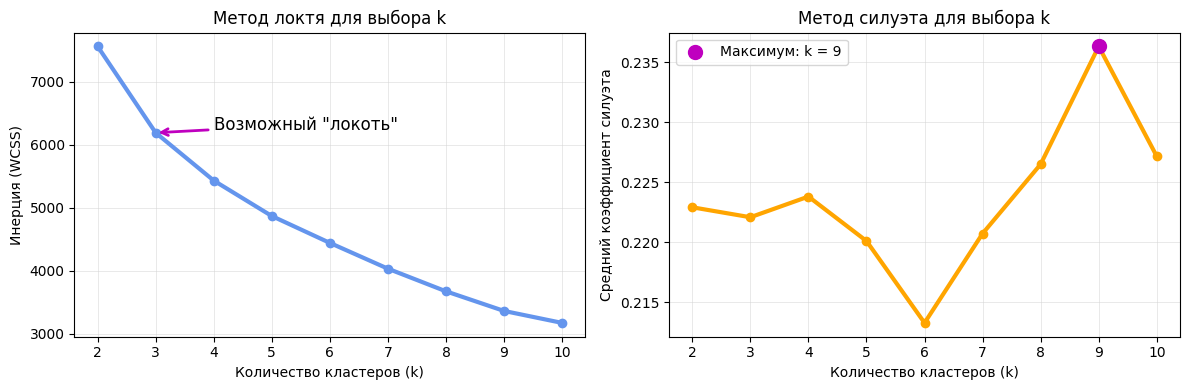

In [337]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(K_range, inertia, marker='o', linestyle='-', linewidth=3, color='cornflowerblue')
axes[0].set_xlabel('Количество кластеров (k)')
axes[0].set_ylabel('Инерция (WCSS)')
axes[0].set_title('Метод локтя для выбора k')
axes[0].grid(True, color='lightgray', linewidth=0.5, alpha=0.7)
axes[0].annotate('Возможный "локоть"', xy=(3, inertia[1]), xytext=(4, inertia[1]+50), arrowprops=dict(arrowstyle='->', linewidth=2, color='m'), fontsize=12)

axes[1].plot(K_range, silhouette_scores, marker='o', linestyle='-', linewidth=3, color='orange')
axes[1].set_xlabel('Количество кластеров (k)')
axes[1].set_ylabel('Средний коэффициент силуэта')
axes[1].set_title('Метод силуэта для выбора k')
axes[1].grid(True, color='lightgray', linewidth=0.5, alpha=0.7)
axes[1].scatter(9,silhouette_scores[7], color='m', s=100, zorder=5, label=f'Максимум: k = 9')
axes[1].legend()

plt.tight_layout()
plt.show()


Метод локтя показывает замедление падения инерции после `k = 3`, метод силуэта  показывает максимум при `k = 9`

При выборе k равным 9 получится разбиение на 9 "групп" студентов, что сложно содержательно различить и описать. Оптимальным k было выбрано значение 3

In [338]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_final.fit(X_scaled)

df['Cluster'] = kmeans_final.labels_

#### **Визуализация результатов**

##### PCA проекция

Так как у нас многомерные данные (5 признаков), нам нужно уменьшить размерность для визуализации на плоскости. Используем **PCA (Principal Component Analysis)** для проекции на 2 главные компоненты

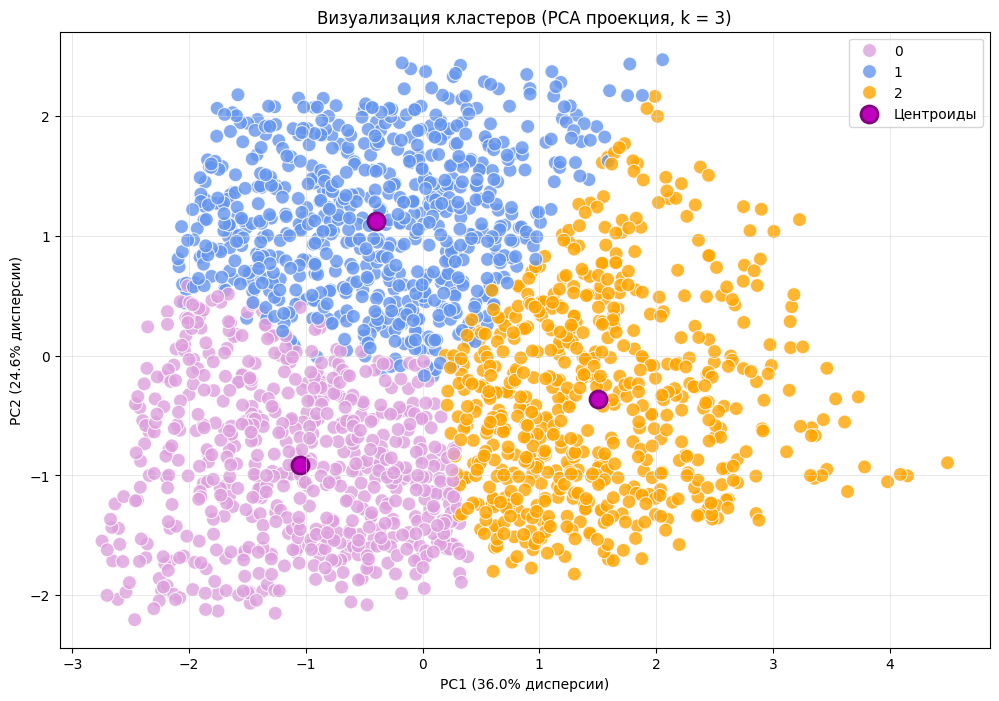

In [339]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

viz_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
viz_df['Cluster'] = df['Cluster'].values
viz_df['Gender'] = df['Gender'].values
viz_df['Stress_Level'] = df['Stress_Level'].values
viz_df['Grades'] = df['Grades'].values

plt.figure(figsize=(12, 8))

cluster_colors = ['plum', 'cornflowerblue', 'orange']
sns.scatterplot(data=viz_df, x='PC1', y='PC2', hue='Cluster', palette=cluster_colors, s=100, alpha=0.8)

centroids_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], marker='o', s=150, c='m', edgecolor='purple', linewidth=2, label='Центроиды')

plt.title(f'Визуализация кластеров (PCA проекция, k = {optimal_k})')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} дисперсии)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} дисперсии)')
plt.legend()

plt.grid(True, color='lightgray', linewidth=0.5, alpha=0.7)
plt.show()

#### Вклад признаков в главные компоненты

In [340]:
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=features_for_clustering)

display(loadings.round(2))

,PC1,PC2
Study_Hours_Per_Day,-0.43,-0.14
Extracurricular_Hours_Per_Day,-0.31,-0.22
Sleep_Hours_Per_Day,-0.41,-0.36
Social_Hours_Per_Day,-0.15,0.87
Physical_Activity_Hours_Per_Day,0.73,-0.20


##### Сводка по кластерам

In [341]:
cluster_summary = df.groupby('Cluster').agg({**{feat: 'mean' for feat in features_for_clustering}, 'Grades': 'mean', 'Student_ID': 'count'}).rename(columns={'Student_ID': 'Count'})

display(cluster_summary.round(2))

,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,Grades,Count
Cluster,,,,,,,
0,8.40,2.51,8.60,1.61,2.87,8.11,638
1,7.36,1.92,7.21,4.49,3.03,7.76,724
2,6.68,1.56,6.73,1.77,7.26,7.50,638


##### Визуализируем профили кластеров

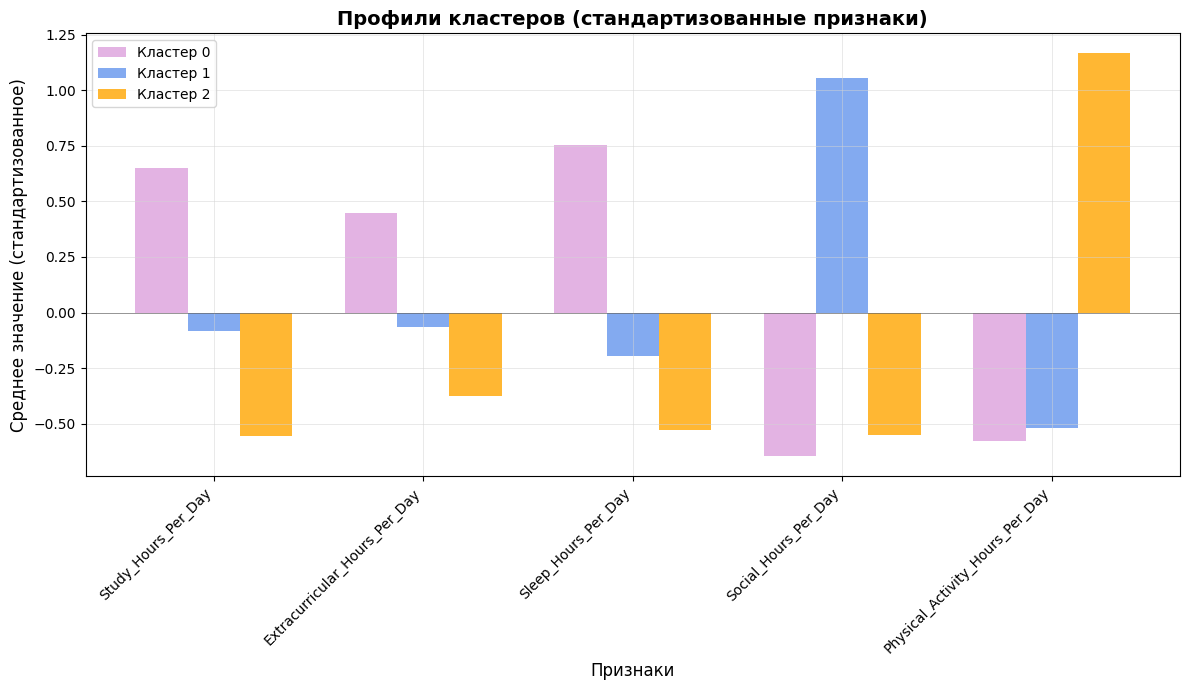

In [342]:
cluster_centers_scaled = pd.DataFrame(kmeans_final.cluster_centers_, columns=features_for_clustering).T
colors = ['plum', 'cornflowerblue', 'orange']

fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(cluster_centers_scaled.index))
width = 0.25

for i, color in enumerate(colors):
    ax.bar(x + i*width, cluster_centers_scaled.iloc[:, i], width, label=f'Кластер {i}', color=color, alpha=0.8)

ax.set_xlabel('Признаки', fontsize=12)
ax.set_ylabel('Среднее значение (стандартизованное)', fontsize=12)
ax.set_title('Профили кластеров (стандартизованные признаки)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(cluster_centers_scaled.index, rotation=45, ha='right')
ax.legend()
ax.grid(True, color='lightgray', linewidth=0.5, alpha=0.7)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.show()

#### **Выводы**

Выделяются 3 характерные группы:
- **Отличники** – студенты, кторые много времени тратят на учебу, внеклассные дополнительные занятия, хорошо спят, меньше всех общаются и занимаются спортом
- **Социально активные студенты** – лидеры в количестве часов общения в сутки и "среднячки" в остальном
- **Спортсмены** – студенты, которые большинство времени уделяют спорту, а также имеют наименьшие остальные хаарктеристики

Такая классификация студентов очень логично может быть "в реальности" и мне кажется модель классификации получила отличный результат, четко выделив кластеры

## **Вывод**

##### **Ключевой фактор успеваемости**
При помощи статистических методов, а также при получении коэффициентов модели линейной регрессии подтверждена единственная сильная прямая взаимосвязь между количеством часов учебы в день и средним баллом. Проанализированы и визуализированы взаимосвязи других атрибутов

##### **Проверка гипотез**
Статистически значимой связи между полом студента и количеством сна не обнаружено. Гипотеза о влиянии сна на оценки также не подтвердилась – линейной или квадратичной зависимости не выявлено

##### **Модель линейной регрессии**
Построенная модель линейной регрессии позволяет прогнозировать средний балл с приемлемой точностью (ошибка MAE ~0.41 балл) и объясняет 55% вариации оценок

##### **Модель кластеризации**
Кластерный анализ выделил три характерных типа студентов: «Отличники», «Социально активные» и «Спортсмены», которые логично интерпретируются "в реальность"

#### **Подводя итог,**
В работе продемонстрировано использование различных методов для анализа данных в Python, построены множество разных визуализаций, использованы статистические инструменты, выполнена агрегация и группировка. Проведена предварительная подготовка данных, разведочный анализ и построены две ML модели, что позволило достичь поставленной цели — проанализировать ключевые взаимосвязи между образом жизни и успеваемостью студентов